In [2]:
using LinearAlgebra
using BSplineKit
using DelimitedFiles
using Plots
using NonlinearEigenproblems
include("BaseFlow_cavity.jl")

mode = 1:cavity; mode = 2:stationary; mode = 3:rotation;


In [4]:
function baseflow(Res,Ro,Ts,mode,N_cheb)
    Co = 2 - Ro - Ro^2
    u0,v0,w0,du0,dv0,x = CRC_BF.BaseFlow(Res,Ro,Ts,mode)
    D,D2,z = CRC_BF.Cheb(N_cheb,mode)
    F,G,H = CRC_BF.interp(u0,v0,w0,z,N_cheb,mode)
    return F,G,H,D,D2,x
end
function eigsolve(F,G,H,Res,Ro,mode,N_cheb,c,R,omega,be)
    cof = Spatial_mode_BEK1((F),(G.-1),(H),R,N_cheb,D,D2,Res)
    L0_raw,L1_raw,L2_raw= assemble_mat(cof,D,D2,be,omega,R)
    L0,L1,L2 = boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb,mode)
    nep = PEP([L0,L1,L2]);
    nep = PEP([L0,L1,L2]);
    eigval,eigvec = iar(nep, σ = c, neigs = 1,maxit = 500 , tol=1e-14)
    vel = eig_full(eigvec,N_cheb,1)
    A0_raw = transpose(cof.D1) + (im * R * be * transpose(cof.B)) - (im * omega * transpose(cof.Ta)) - (be^2 * R^2 * transpose(cof.Vyy)) - transpose(cof.dC) - (im *be*transpose(cof.dVyz)) + transpose(cof.d2Vzz) - (transpose(cof.C) + im * be * R * transpose(cof.Vyz) - 2 * transpose(cof.dVzz)) * kron(I(4),D) + transpose(cof.Vzz) * kron(I(4),D2)
    A1_raw = (im * transpose(cof.A)) - (be * R * transpose(cof.Vxy)) - (im * transpose(cof.dVxz)) - (im * transpose(cof.Vxz)) * kron(I(4),D) 
    A2_raw = -transpose(cof.Vxx)
    A0,A1,A2 = boudary_condition(A0_raw,A1_raw,A2_raw,N_cheb,mode)
    nep1 = PEP([A0,A1,A2]);
    eigval_A,eigvec_A = iar(nep1, σ = c, neigs = 1,maxit = 500 , tol=1e-14)
    vel_A = eig_full(eigvec,N_cheb,1)
    return eigval,eigval_A,eigvec,eigvec_A,[L1,L2]
end
function normalization(eigvec,eigvec_A)
    vel = eig_full(eigvec,N_cheb,1)
    vel_A = eig_full(eigvec_A,N_cheb,1)
    eigvec = eigvec./findmax(abs.(vel[2]))[1]
    eigvec_A = eigvec_A./findmax(abs.(vel_A[1]))[1]
    vel = eig_full(eigvec,N_cheb,1)
    vel_A = eig_full(eigvec_A,N_cheb,1)
    return eigvec,eigvec_A,vel,vel_A
end
function Cr_receptivity(hr,ls,eigval,F,G,R,vel_A,Q)
    Hx = hr*exp(-(eigval[1])^2/(4*ls))*sqrt(pi/ls)
    u_wall = -(D*F)[1] * Hx
    v_wall = -(D*G)[1] * Hx
    w_wall = 0 
    item_2 = (1/R) * (D*vel_A[1])[1] * u_wall
    item_3 = (1/R) * (D*vel_A[2])[1] * v_wall
    BC =  (item_2 + item_3)/sqrt(Res)
    Cr = abs(-im * BC/Q[1])
    return Cr,BC
end
function Q_receptivity(eigvec_A,eigvec,eigval,eigval_A,L,w)
    Q = transpose(eigvec_A[:,1]) * w * (L[1] + (eigval[1] + eigval_A[1]) * L[2]) * eigvec[:,1]
    return Q
end
function cheb_quad(N::Int)
    N_cheb = N

    x = [cos(pi * j / N) for j in 0:N]
    
    w = zeros(N + 1)
    
    n = 0:N
    for j in 0:N
        s = 0.0
        for k in 1:floor(Int, N/2)
            term = 2.0 / (1.0 - (2*k)^2) * cos(2 * k * j * pi / N)
            if 2*k == N
                s += 0.5 * term
            else
                s += term
            end
        end
        c_j = (j == 0 || j == N) ? 1.0 : 2.0
        w[j+1] = (c_j / N) * (1.0 + s)
    end
    a = 6
    b = 0.6
    c = 0.5
    Jac = zeros(N_cheb+1,N_cheb+1)
    x = reverse(x)
    for i = 1 : 1 : N_cheb + 1
        Jac[i,i] = 1/2
    end
    # Jac[end,end] = 1e10
    w1 = kron(I(4),diagm(Jac * w))
    w1 = w1[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3))]
    return w1
end

cheb_quad (generic function with 1 method)

In [7]:
Res = 1000
N_cheb = 149
mode = 1
Ro = - 1.0
R = 282
be = 0.09
OMEGA = -4.0
hr = 1/Res
ls = 1/2
omega = OMEGA/R
c = 0.4
Ts = 0.0
F,G,H,D,D2,z = baseflow(Res,Ro,Ts,mode,N_cheb)
eigval,eigval_A,eigvec,eigvec_A,L = eigsolve(F,G,H,Res,Ro,mode,N_cheb,c,R,omega,be)
eigvec,eigvec_A,vel,vel_A = normalization(eigvec,eigvec_A)
w = cheb_quad(N_cheb)
Q = Q_receptivity(eigvec_A,eigvec,eigval,eigval_A,L,w)
Cr,BC = Cr_receptivity(hr,ls,eigval[1],F,G,R,vel_A,Q)
@show eigval, eigval_A, Cr

(eigval, eigval_A, Cr) = (ComplexF64[0.2202442402113808 + 0.07202217756712309im], ComplexF64[0.22024424020540098 + 0.07202217756969205im], 0.0971822558670942)


(ComplexF64[0.2202442402113808 + 0.07202217756712309im], ComplexF64[0.22024424020540098 + 0.07202217756969205im], 0.0971822558670942)

In [11]:
Res = 1000
N_cheb = 149
mode = 1
F,G,H,D,D2,z = baseflow(Res,Ro,mode,N_cheb)
for OMEGA = [-4.0]
    hr = 1/Res
    ls = 1/2
    for n = 30
        c = 0.02 * n
        coff = zeros(1,9)
        for R = 250 : 2 : 600
            omega = OMEGA/R
            be = n / R
            eigval,eigval_A,eigvec,eigvec_A,L = eigsolve(F,G,H,Res,Ro,mode,N_cheb,c,R,omega,be)
            eigvec,eigvec_A,vel,vel_A = normalization(eigvec,eigvec_A)
            w = cheb_quad(N_cheb)
            Q = Q_receptivity(eigvec_A,eigvec,eigval,eigval_A,L,w)
            Cr,BC = Cr_receptivity(hr,ls,eigval[1],F,G,R,vel_A,Q)
            coff = [coff;[n R Cr abs(Q[1]) abs(BC) real(eigval) imag(eigval) real(eigval_A) imag(eigval_A)]]
            writedlm("Cr_ref_$(n)_$(OMEGA).dat",coff[2:end,:])
            ##
            c = eigval[1]
        end
    end
end

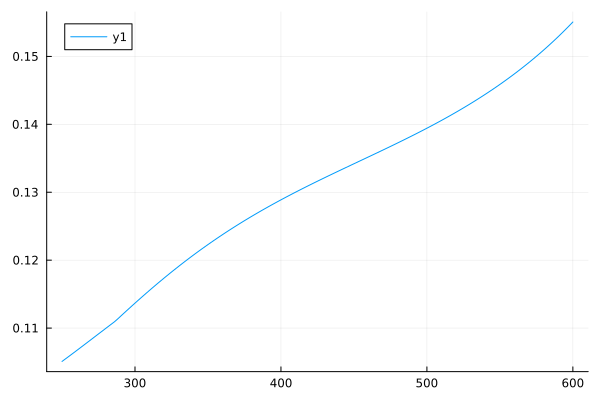

In [38]:
plot(coff[2:end,2],coff[2:end,3])

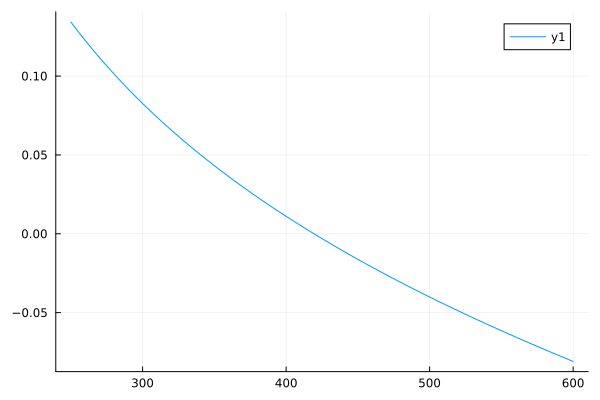

In [39]:
plot(coff[2:end,2],coff[2:end,7])

In [5]:
plot(z,abs.(vel_A[1]))
plot!(z,abs.(vel_A[2]))
plot!(z,abs.(vel_A[3]))

print device already activated
print device already activated


In [6]:
struct COF
        Ta :: Matrix{ComplexF64}
        A :: Matrix{ComplexF64}
        B :: Matrix{ComplexF64}
        C :: Matrix{ComplexF64}
        dC :: Matrix{ComplexF64}
        D1 :: Matrix{ComplexF64}
        Vxx :: Matrix{ComplexF64}
        Vyy :: Matrix{ComplexF64}
        Vzz :: Matrix{ComplexF64}
        dVzz :: Matrix{ComplexF64}
        d2Vzz :: Matrix{ComplexF64}
        Vxy :: Matrix{ComplexF64}
        Vxz :: Matrix{ComplexF64}
        dVxz :: Matrix{ComplexF64}
        Vyz :: Matrix{ComplexF64}
        dVyz :: Matrix{ComplexF64}
end
function Spatial_mode_BEK1(F,G,H,R,N_cheb,D,D2,Res)
    Res0 = sqrt(Res)
    size = N_cheb + 1
    eye = I(N_cheb+1)
    Zero = zeros(N_cheb+1,N_cheb+1)
    Ta = zeros(4*size,4*size)
    A = zeros(4*size,4*size)
    B = zeros(4*size,4*size)
    C = zeros(4*size,4*size)
    D1 = zeros(4*size,4*size)
    Vxy = zeros(4*size,4*size)
    Vxz = zeros(4*size,4*size)
    Vyz = zeros(4*size,4*size)
    Vxx = zeros(4*size,4*size)
    Vyy = zeros(4*size,4*size)
    Vzz = zeros(4*size,4*size)
    dVxz = zeros(4*size,4*size)
    dVyz = zeros(4*size,4*size)
    Ta_11 = eye
    Ta_12 = Ta_13 = Ta_14 = Zero
    Ta_22 = eye
    Ta_21 = Ta_23 = Ta_24 = Zero
    Ta_33 = eye
    Ta_31 = Ta_32 = Ta_34 = Zero
    Ta_41 = Ta_42 = Ta_43 = Ta_44 = Zero

    A_11 = F .* eye
    A_12 = A_13 = Zero
    A_14 = eye
    A_22 = F .* eye
    A_21 = A_23 = A_24 = Zero
    A_31 = A_32 = A_34 = Zero
    A_33 = F .* eye
    A_41 = (1) .* eye
    A_42 = A_43 = A_44 = Zero

    B_11 = (1/R) * G .* eye
    B_12 = B_13 = B_14 = Zero
    B_21 = B_23 = Zero
    B_22 = (1/R) * G .* eye
    B_24 = (1/R) .* eye
    B_31 = B_32 = B_34 = Zero
    B_33 = (1/R) * G .* eye
    B_41 = B_43 = B_44 = Zero
    B_42 = (1/R) .* eye

    C_11 = (1/(R*Res0)) * H .* eye
    dC_11 = D * diag(C_11) .* eye
    C_12 = C_13 = C_14 = Zero
    dC_12 = dC_13 = dC_14 = Zero
    C_22 = (1/(R*Res0)) * H .* eye
    dC_22 = D * diag(C_22) .* eye
    C_21 = C_23 = C_24 = Zero
    dC_21 = dC_23 = dC_24 = Zero
    C_31 = C_32 = Zero
    dC_31 = dC_32 = Zero
    C_33 = (1/(R*Res0)) * H .* eye
    dC_33 = D * diag(C_33) .* eye
    C_34 = 1/Res0 * eye
    dC_34 = D * diag(C_34) .* eye
    C_41 = C_42 = C_44 = Zero
    dC_41 = dC_42 = dC_44 = Zero
    C_43 = (1/Res0) * eye
    dC_43 = D * diag(C_43) .* eye

    D_11 = (1/R) * F .* eye
    D_12 = -(1/R) * 2 * (G.+1) .* eye
    D_13 = 1/Res0 * D * F .* eye
    D_14 = Zero
    D_21 = (1/R) * 2 * (G.+1) .* eye
    D_22 = (1/R) * F .* eye
    D_23 = 1/Res0 * D * G .* eye
    D_24 = Zero
    D_31 = D_32 = D_34 = Zero
    D_33 = (1/(R*Res0)) * D*H.* eye
    D_41 = 1/R .* eye
    D_42 = D_43 = D_44 = Zero

    Vxx_11 = -(1/R) * eye
    Vxx_12 = Vxx_13 = Vxx_14 = Zero
    Vxx_22 = -(1/R) * eye
    Vxx_21 = Vxx_23 = Vxx_24 = Zero
    Vxx_33 = -(1/R) * eye
    Vxx_31 = Vxx_32 = Vxx_34 = Zero
    Vxx_41 = Vxx_42 = Vxx_43 = Vxx_44 = Zero

    Vyy_11 = -(1/R^3) * eye
    Vyy_12 = Vyy_13 = Vyy_14 = Zero
    Vyy_22 = -(1/R^3) * eye
    Vyy_21 = Vyy_23 = Vyy_24 = Zero
    Vyy_33 = -(1/R^3) * eye
    Vyy_31 = Vyy_32 = Vyy_34 = Zero
    Vyy_41 = Vyy_42 = Vyy_43 = Vyy_44 = Zero

    Vzz_11 = -(1/(R*Res)) * eye
    dVzz_11 = D * diag(Vzz_11) .* eye
    d2Vzz_11 = D2 * diag(Vzz_11) .* eye
    Vzz_12 = Vzz_13 = Vzz_14 = Zero
    dVzz_12 = dVzz_13 = dVzz_14 = Zero
    d2Vzz_12 = d2Vzz_13 = d2Vzz_14 = Zero
    Vzz_22 =  -(1/(R*Res)) * eye
    dVzz_22 = D * diag(Vzz_22) .* eye
    d2Vzz_22 = D2 * diag(Vzz_22) .* eye
    Vzz_21 = Vzz_23 = Vzz_24 = Zero
    dVzz_21 = dVzz_23 = dVzz_24 = Zero
    d2Vzz_21 = d2Vzz_23 = d2Vzz_24 = Zero
    Vzz_33 =  -(1/(R*Res)) * eye
    dVzz_33 = D * diag(Vzz_33) .* eye
    d2Vzz_33 = D2 * diag(Vzz_33) .* eye
    Vzz_31 = Vzz_32 = Vzz_34 = Zero
    dVzz_31 = dVzz_32 = dVzz_34 = Zero
    d2Vzz_31 = d2Vzz_32 = d2Vzz_34 = Zero
    Vzz_41 = Vzz_42 = Vzz_43 = Vzz_44 = Zero
    dVzz_41 = dVzz_42 = dVzz_43 = dVzz_44 = Zero
    d2Vzz_41 = d2Vzz_42 = d2Vzz_43 = d2Vzz_44 = Zero

    Vxy = zeros(4*size,4*size)
    dVxy = zeros(4*size,4*size)
    Vxz = zeros(4*size,4*size)
    Vyz = zeros(4*size,4*size)

    Ta = [Ta_11 Ta_12 Ta_13 Ta_14;Ta_21 Ta_22 Ta_23 Ta_24;Ta_31 Ta_32 Ta_33 Ta_34;Ta_41 Ta_42 Ta_43 Ta_44]
    A = [A_11 A_12 A_13 A_14;A_21 A_22 A_23 A_24;A_31 A_32 A_33 A_34;A_41 A_42 A_43 A_44]
    B = [B_11 B_12 B_13 B_14;B_21 B_22 B_23 B_24;B_31 B_32 B_33 B_34;B_41 B_42 B_43 B_44]
    C = [C_11 C_12 C_13 C_14;C_21 C_22 C_23 C_24;C_31 C_32 C_33 C_34;C_41 C_42 C_43 C_44]
    dC = [dC_11 dC_12 dC_13 dC_14;dC_21 dC_22 dC_23 dC_24;dC_31 dC_32 dC_33 dC_34;dC_41 dC_42 dC_43 dC_44]
    D1 = [D_11 D_12 D_13 D_14;D_21 D_22 D_23 D_24;D_31 D_32 D_33 D_34;D_41 D_42 D_43 D_44]
    Vxx = [Vxx_11 Vxx_12 Vxx_13 Vxx_14;Vxx_21 Vxx_22 Vxx_23 Vxx_24;Vxx_31 Vxx_32 Vxx_33 Vxx_34;Vxx_41 Vxx_42 Vxx_43 Vxx_44]
    Vyy = [Vyy_11 Vyy_12 Vyy_13 Vyy_14;Vyy_21 Vyy_22 Vyy_23 Vyy_24;Vyy_31 Vyy_32 Vyy_33 Vyy_34;Vyy_41 Vyy_42 Vyy_43 Vyy_44]
    Vzz = [Vzz_11 Vzz_12 Vzz_13 Vzz_14;Vzz_21 Vzz_22 Vzz_23 Vzz_24;Vzz_31 Vzz_32 Vzz_33 Vzz_34;Vzz_41 Vzz_42 Vzz_43 Vzz_44]
    dVzz = [dVzz_11 dVzz_12 dVzz_13 dVzz_14;dVzz_21 dVzz_22 dVzz_23 dVzz_24;dVzz_31 dVzz_32 dVzz_33 dVzz_34;dVzz_41 dVzz_42 dVzz_43 dVzz_44]
    d2Vzz = [d2Vzz_11 d2Vzz_12 d2Vzz_13 d2Vzz_14;d2Vzz_21 d2Vzz_22 d2Vzz_23 d2Vzz_24;d2Vzz_31 d2Vzz_32 d2Vzz_33 d2Vzz_34;d2Vzz_41 d2Vzz_42 d2Vzz_43 d2Vzz_44]
    return COF(Ta,A,B,C,dC,D1,Vxx,Vyy,Vzz,dVzz,d2Vzz,Vxy,Vxz,dVxz,Vyz,dVyz)
end
function Spatial_mode_BEK2(F,G,H,R,N_cheb,D,D2,Ro,Co)
    if Ro == -1
        Ro *= -1
    end
    size = N_cheb + 1
    eye = I(N_cheb+1)
    Zero = zeros(N_cheb+1,N_cheb+1)
    Ta = zeros(4*size,4*size)
    A = zeros(4*size,4*size)
    B = zeros(4*size,4*size)
    C = zeros(4*size,4*size)
    D1 = zeros(4*size,4*size)
    Vxy = zeros(4*size,4*size)
    Vxz = zeros(4*size,4*size)
    Vyz = zeros(4*size,4*size)
    Vxx = zeros(4*size,4*size)
    Vyy = zeros(4*size,4*size)
    Vzz = zeros(4*size,4*size)
    dVxz = zeros(4*size,4*size)
    dVyz = zeros(4*size,4*size)
    Ta_11 = eye
    Ta_12 = Ta_13 = Ta_14 = Zero
    Ta_22 = eye
    Ta_21 = Ta_23 = Ta_24 = Zero
    Ta_33 = eye
    Ta_31 = Ta_32 = Ta_34 = Zero
    Ta_41 = Ta_42 = Ta_43 = Ta_44 = Zero

    A_11 = F .* eye
    A_12 = A_13 = Zero
    A_14 = eye
    A_22 = F .* eye
    A_21 = A_23 = A_24 = Zero
    A_31 = A_32 = A_34 = Zero
    A_33 = F .* eye
    A_41 = eye
    A_42 = A_43 = A_44 = Zero

    B_11 = (1/R) * G .* eye
    B_12 = B_13 = B_14 = Zero
    B_21 = B_23 = Zero
    B_22 = (1/R) * G .* eye
    B_24 = (1/R) .* eye
    B_31 = B_32 = B_34 = Zero
    B_33 = (1/R) * G .* eye
    B_41 = B_43 = B_44 = Zero
    B_42 = (1/R) .* eye

    C_11 = (Ro/(R)) * H .* eye
    dC_11 = D * diag(C_11) .* eye
    C_12 = C_13 = C_14 = Zero
    dC_12 = dC_13 = dC_14 = Zero
    C_22 = (Ro/(R)) * H .* eye
    dC_22 = D * diag(C_22) .* eye
    C_21 = C_23 = C_24 = Zero
    dC_21 = dC_23 = dC_24 = Zero
    C_31 = C_32 = Zero
    dC_31 = dC_32 = Zero
    C_33 = (Ro/(R)) * H .* eye
    dC_33 = D * diag(C_33) .* eye
    C_34 = 1 * eye
    dC_34 = D * diag(C_34) .* eye
    C_41 = C_42 = C_44 = Zero
    dC_41 = dC_42 = dC_44 = Zero
    C_43 = (1) * eye
    dC_43 = D * diag(C_43) .* eye

    D_11 = (Ro/R) * F .* eye
    D_12 = -(1/R) * (2*Ro*G.+ Co) .* eye
    D_13 = D * F .* eye
    D_14 = Zero
    D_21 = (1/R) * (2*Ro*G.+ Co) .* eye
    D_22 = (Ro/R) * F .* eye
    D_23 = D * G .* eye
    D_24 = Zero
    D_31 = D_32 = D_34 = Zero
    D_33 = (Ro/(R)) * D*H.* eye
    D_41 = Ro/R .* eye
    D_42 = D_43 = D_44 = Zero

    Vxx_11 = -(1/R) * eye
    Vxx_12 = Vxx_13 = Vxx_14 = Zero
    Vxx_22 = -(1/R) * eye
    Vxx_21 = Vxx_23 = Vxx_24 = Zero
    Vxx_33 = -(1/R) * eye
    Vxx_31 = Vxx_32 = Vxx_34 = Zero
    Vxx_41 = Vxx_42 = Vxx_43 = Vxx_44 = Zero

    Vyy_11 = -(1/R^3) * eye
    Vyy_12 = Vyy_13 = Vyy_14 = Zero
    Vyy_22 = -(1/R^3) * eye
    Vyy_21 = Vyy_23 = Vyy_24 = Zero
    Vyy_33 = -(1/R^3) * eye
    Vyy_31 = Vyy_32 = Vyy_34 = Zero
    Vyy_41 = Vyy_42 = Vyy_43 = Vyy_44 = Zero

    Vzz_11 = -(1/(R)) * eye
    dVzz_11 = D * diag(Vzz_11) .* eye
    d2Vzz_11 = D2 * diag(Vzz_11) .* eye
    Vzz_12 = Vzz_13 = Vzz_14 = Zero
    dVzz_12 = dVzz_13 = dVzz_14 = Zero
    d2Vzz_12 = d2Vzz_13 = d2Vzz_14 = Zero
    Vzz_22 =  -(1/(R)) * eye
    dVzz_22 = D * diag(Vzz_22) .* eye
    d2Vzz_22 = D2 * diag(Vzz_22) .* eye
    Vzz_21 = Vzz_23 = Vzz_24 = Zero
    dVzz_21 = dVzz_23 = dVzz_24 = Zero
    d2Vzz_21 = d2Vzz_23 = d2Vzz_24 = Zero
    Vzz_33 =  -(1/(R)) * eye
    dVzz_33 = D * diag(Vzz_33) .* eye
    d2Vzz_33 = D2 * diag(Vzz_33) .* eye
    Vzz_31 = Vzz_32 = Vzz_34 = Zero
    dVzz_31 = dVzz_32 = dVzz_34 = Zero
    d2Vzz_31 = d2Vzz_32 = d2Vzz_34 = Zero
    Vzz_41 = Vzz_42 = Vzz_43 = Vzz_44 = Zero
    dVzz_41 = dVzz_42 = dVzz_43 = dVzz_44 = Zero
    d2Vzz_41 = d2Vzz_42 = d2Vzz_43 = d2Vzz_44 = Zero

    Vxy = zeros(4*size,4*size)
    Vxz = zeros(4*size,4*size)
    Vyz = zeros(4*size,4*size)

    Ta = [Ta_11 Ta_12 Ta_13 Ta_14;Ta_21 Ta_22 Ta_23 Ta_24;Ta_31 Ta_32 Ta_33 Ta_34;Ta_41 Ta_42 Ta_43 Ta_44]
    A = [A_11 A_12 A_13 A_14;A_21 A_22 A_23 A_24;A_31 A_32 A_33 A_34;A_41 A_42 A_43 A_44]
    B = [B_11 B_12 B_13 B_14;B_21 B_22 B_23 B_24;B_31 B_32 B_33 B_34;B_41 B_42 B_43 B_44]
    C = [C_11 C_12 C_13 C_14;C_21 C_22 C_23 C_24;C_31 C_32 C_33 C_34;C_41 C_42 C_43 C_44]
    dC = [dC_11 dC_12 dC_13 dC_14;dC_21 dC_22 dC_23 dC_24;dC_31 dC_32 dC_33 dC_34;dC_41 dC_42 dC_43 dC_44]
    D1 = [D_11 D_12 D_13 D_14;D_21 D_22 D_23 D_24;D_31 D_32 D_33 D_34;D_41 D_42 D_43 D_44]
    Vxx = [Vxx_11 Vxx_12 Vxx_13 Vxx_14;Vxx_21 Vxx_22 Vxx_23 Vxx_24;Vxx_31 Vxx_32 Vxx_33 Vxx_34;Vxx_41 Vxx_42 Vxx_43 Vxx_44]
    Vyy = [Vyy_11 Vyy_12 Vyy_13 Vyy_14;Vyy_21 Vyy_22 Vyy_23 Vyy_24;Vyy_31 Vyy_32 Vyy_33 Vyy_34;Vyy_41 Vyy_42 Vyy_43 Vyy_44]
    Vzz = [Vzz_11 Vzz_12 Vzz_13 Vzz_14;Vzz_21 Vzz_22 Vzz_23 Vzz_24;Vzz_31 Vzz_32 Vzz_33 Vzz_34;Vzz_41 Vzz_42 Vzz_43 Vzz_44]
    dVzz = [dVzz_11 dVzz_12 dVzz_13 dVzz_14;dVzz_21 dVzz_22 dVzz_23 dVzz_24;dVzz_31 dVzz_32 dVzz_33 dVzz_34;dVzz_41 dVzz_42 dVzz_43 dVzz_44]
    d2Vzz = [d2Vzz_11 d2Vzz_12 d2Vzz_13 d2Vzz_14;d2Vzz_21 d2Vzz_22 d2Vzz_23 d2Vzz_24;d2Vzz_31 d2Vzz_32 d2Vzz_33 d2Vzz_34;d2Vzz_41 d2Vzz_42 d2Vzz_43 d2Vzz_44]
    return COF(Ta,A,B,C,dC,D1,Vxx,Vyy,Vzz,dVzz,d2Vzz,Vxy,Vxz,dVxz,Vyz,dVyz)
end
function assemble_mat(cof,D,D2,be,omega,R)
    L0 = cof.D1  + im * R * be * cof.B - im * omega * cof.Ta - be^2 * R^2 * cof.Vyy + (cof.C .+ im * be * R * cof.Vyz) * kron(I(4), D)  + (cof.Vzz) * kron(I(4),D2) 
    L1 = im * cof.A - be * R * cof.Vxy + im *  cof.Vxz * kron(I(4),D)
    L2 = -cof.Vxx 
    return L0,L1,L2
end
function assemble_adjmat(cof,D,D2,be,omega,R)
    A0_raw = transpose(cof.D1) + (im * be * R * transpose(cof.B)) - (im * omega * transpose(cof.Ta)) - (be^2 * R * transpose(cof.Vyy)) - transpose(cof.dC) - (im * be * R * transpose(cof.dVyz)) + transpose(cof.d2Vzz) - (transpose(cof.C) + im * be * R * transpose(cof.Vyz) - 2 * transpose(cof.dVzz)) * kron(I(4),D) + transpose(cof.Vzz) * kron(I(4),D2)
    A1_raw = (im * transpose(cof.A)) - (be * R * transpose(cof.Vxy)) - (im * transpose(cof.dVxz)) - (im * transpose(cof.Vxz)) * kron(I(4),D) 
    A2_raw = -transpose(cof.Vxx)
    return A0_raw,A1_raw,A2_raw
end
function boudary_condition(L0,L1,L2,N_cheb,mode)
    if mode == 1 
        L0 = L0[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3))]
        L1 = L1[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3))]
        L2 = L2[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3))]
    elseif mode == 3
        L0 = L0[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4))]
        L1 = L1[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4))]
        L2 = L2[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4))]
    end
    return L0,L1,L2
end
function eig_full(eigvec,N_cheb,num)
    N = N_cheb + 1
    eigvec = eigvec[:,num]
    insert!(eigvec,4N-8,0im)
    insert!(eigvec,3N-5,0im)
    insert!(eigvec,3N-5,0im)
    insert!(eigvec,2N-3,0im)
    insert!(eigvec,2N-3,0im)
    insert!(eigvec,N-1,0im)
    insert!(eigvec,N-1,0im)
    insert!(eigvec,1,0im)
    u = eigvec[1:N]
    v = eigvec[N+1:2N]
    w = eigvec[2N+1:3N]
    p = eigvec[3N+1:4N]
    return (u,v,w,p)
end

eig_full (generic function with 1 method)